In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
import os
sys.path.append('../analytics')

from engine import StockAnalytics


plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.facecolor'] = '#0f0f0f'
plt.rcParams['figure.facecolor'] = '#0f0f0f'
plt.rcParams['axes.edgecolor'] = '#333'
plt.rcParams['axes.labelcolor'] = '#999'
plt.rcParams['xtick.color'] = '#666'
plt.rcParams['ytick.color'] = '#666'
plt.rcParams['text.color'] = '#e5e5e5'
plt.rcParams['grid.color'] = '#1a1a1a'
plt.rcParams['grid.linestyle'] = '--'

print("Setup complete")

Setup complete


In [11]:

s = StockAnalytics('AAPL')
s.run_all()
df = s.df.copy()

print(f"Loaded {len(df)} rows for AAPL")
print(f"Columns: {list(df.columns)}")
print(f"\nSummary:")
for key, val in s.summary().items():
    print(f"  {key}: {val}")

Loaded 123 rows for AAPL
Loaded 123 rows for AAPL
Columns: ['ticker', 'date', 'open', 'high', 'low', 'close', 'volume', 'sma_20', 'sma_50', 'ema_12', 'ema_26', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_upper', 'bb_middle', 'bb_lower', 'obv', 'vol_sma_20', 'vol_ratio', 'daily_return', 'rolling_std', 'annual_vol', 'signal']

Summary:
  ticker: AAPL
  total_return_pct: 10.63
  sharpe_ratio: 1.06
  max_drawdown_pct: -11.35
  annual_vol_pct: 19.06
  rsi_current: 53.4
  signal_current: hold
  latest_close: 301.54
  data_from: 2025-12-30
  data_to: 2026-06-08


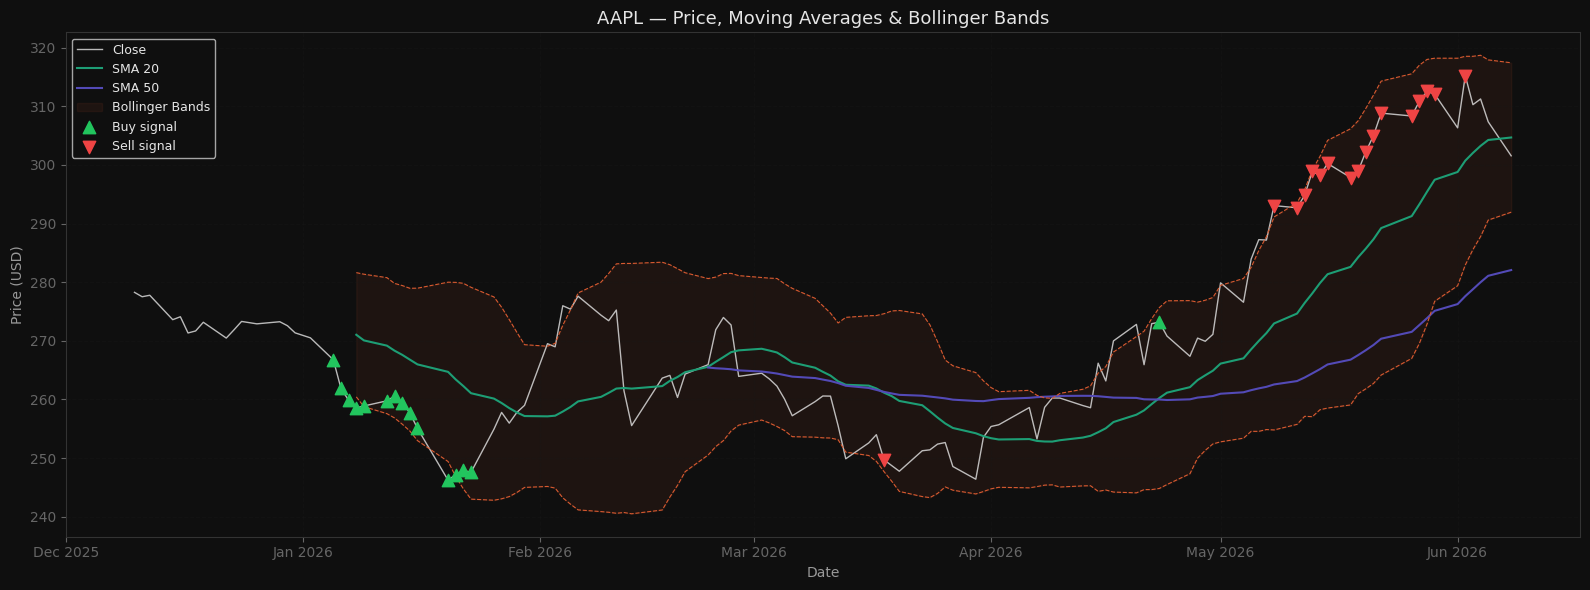

In [12]:
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(df['date'], df['close'],  color='#e5e5e5', linewidth=1,   label='Close',  alpha=0.8)
ax.plot(df['date'], df['sma_20'], color='#1D9E75', linewidth=1.5, label='SMA 20')
ax.plot(df['date'], df['sma_50'], color='#534AB7', linewidth=1.5, label='SMA 50')
ax.fill_between(df['date'], df['bb_upper'], df['bb_lower'],
                color='#D85A30', alpha=0.08, label='Bollinger Bands')
ax.plot(df['date'], df['bb_upper'], color='#D85A30', linewidth=0.8, linestyle='--')
ax.plot(df['date'], df['bb_lower'], color='#D85A30', linewidth=0.8, linestyle='--')


buys  = df[df['signal'] == 'buy']
sells = df[df['signal'] == 'sell']
ax.scatter(buys['date'],  buys['close'],  color='#22c55e', marker='^', s=80, zorder=5, label='Buy signal')
ax.scatter(sells['date'], sells['close'], color='#ef4444', marker='v', s=80, zorder=5, label='Sell signal')

ax.set_title('AAPL — Price, Moving Averages & Bollinger Bands', color='#e5e5e5', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('aapl_moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()

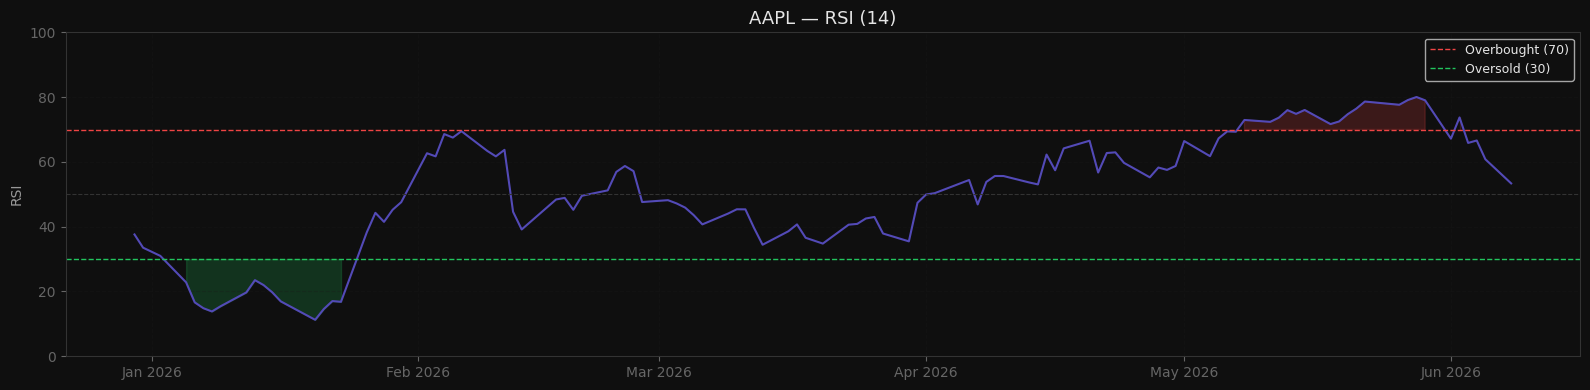

In [13]:
fig, ax = plt.subplots(figsize=(16, 4))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

rsi_data = df.dropna(subset=['rsi_14'])
ax.plot(rsi_data['date'], rsi_data['rsi_14'], color='#534AB7', linewidth=1.5)
ax.axhline(y=70, color='#ef4444', linestyle='--', linewidth=1, label='Overbought (70)')
ax.axhline(y=30, color='#22c55e', linestyle='--', linewidth=1, label='Oversold (30)')
ax.axhline(y=50, color='#333',    linestyle='--', linewidth=0.8)

ax.fill_between(rsi_data['date'], rsi_data['rsi_14'], 70,
                where=rsi_data['rsi_14'] >= 70, color='#ef4444', alpha=0.2)
ax.fill_between(rsi_data['date'], rsi_data['rsi_14'], 30,
                where=rsi_data['rsi_14'] <= 30, color='#22c55e', alpha=0.2)

ax.set_title('AAPL — RSI (14)', color='#e5e5e5', fontsize=13)
ax.set_ylabel('RSI')
ax.set_ylim(0, 100)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('aapl_rsi.png', dpi=150, bbox_inches='tight')
plt.show()

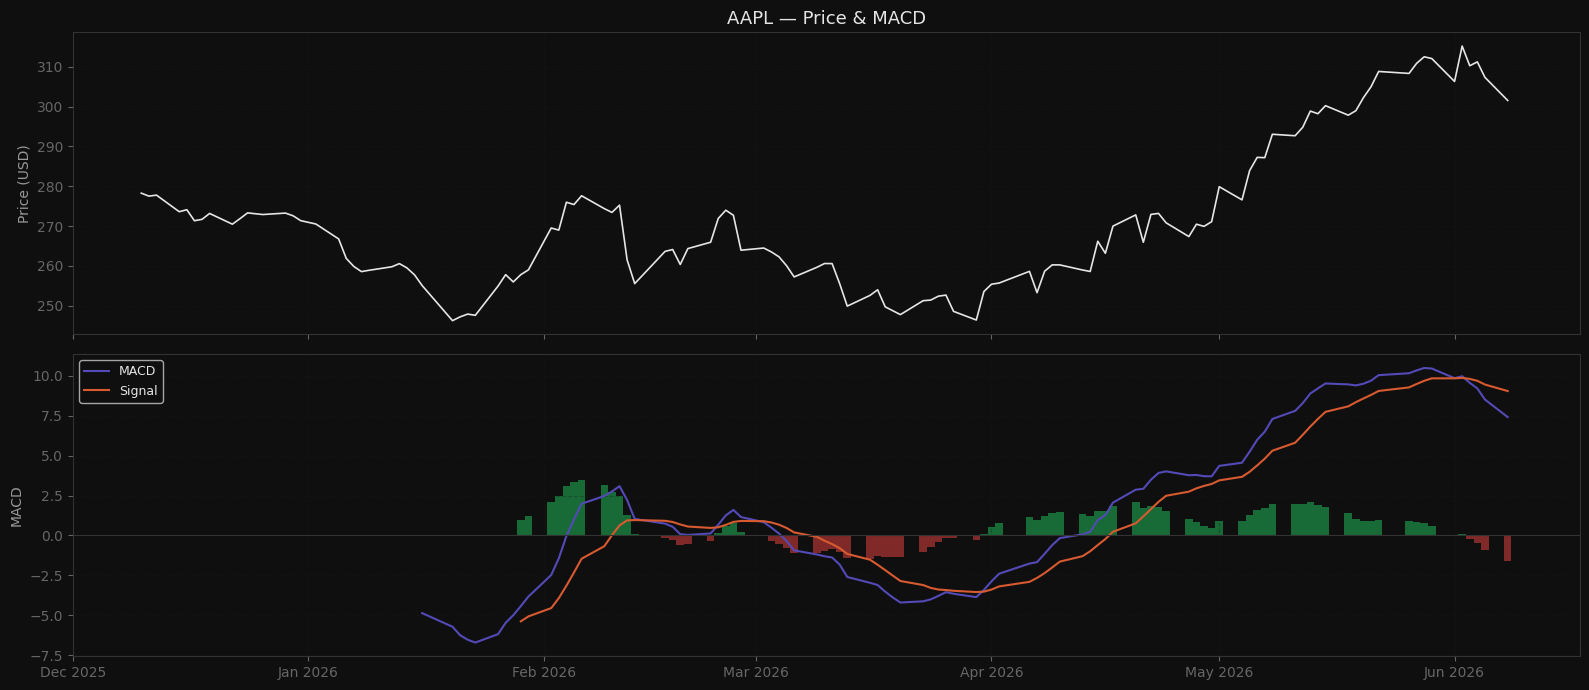

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1]})
fig.patch.set_facecolor('#0f0f0f')

macd_data = df.dropna(subset=['macd'])



ax1.plot(df['date'], df['close'], color='#e5e5e5', linewidth=1.2)
ax1.set_facecolor('#0f0f0f')
ax1.set_ylabel('Price (USD)')
ax1.set_title('AAPL — Price & MACD', color='#e5e5e5', fontsize=13)
ax1.grid(True, alpha=0.3)


ax2.set_facecolor('#0f0f0f')
ax2.plot(macd_data['date'], macd_data['macd'],        color='#534AB7', linewidth=1.5, label='MACD')
ax2.plot(macd_data['date'], macd_data['macd_signal'], color='#D85A30', linewidth=1.5, label='Signal')
ax2.bar(macd_data['date'], macd_data['macd_hist'],
        color=macd_data['macd_hist'].apply(lambda x: '#22c55e' if x >= 0 else '#ef4444'),
        alpha=0.5, width=1)
ax2.axhline(y=0, color='#333', linewidth=0.8)
ax2.set_ylabel('MACD')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('aapl_macd.png', dpi=150, bbox_inches='tight')
plt.show()

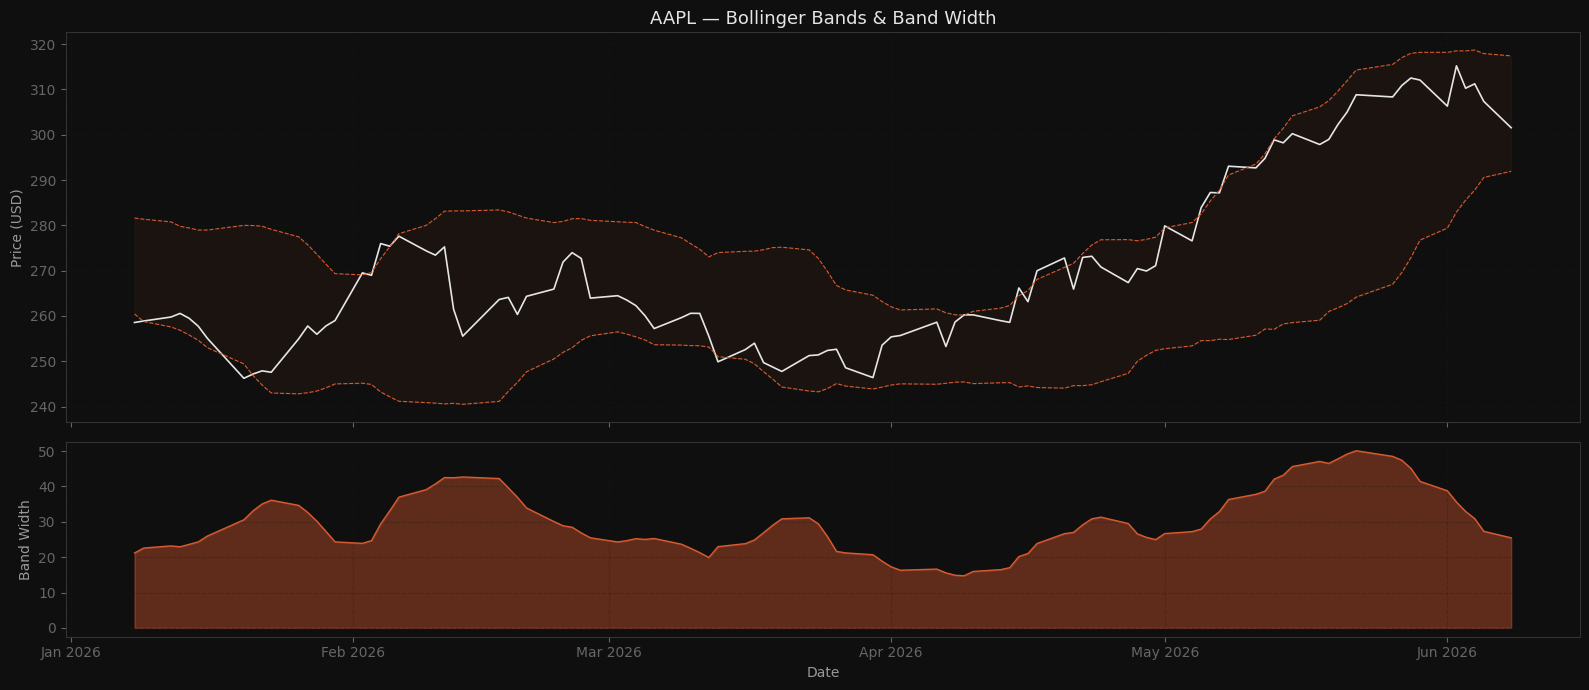

In [15]:
df_bb = df.dropna(subset=['bb_upper', 'bb_lower'])
df_bb = df_bb.copy()
df_bb['bb_width'] = df_bb['bb_upper'] - df_bb['bb_lower']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})
fig.patch.set_facecolor('#0f0f0f')

ax1.set_facecolor('#0f0f0f')
ax1.plot(df_bb['date'], df_bb['close'],    color='#e5e5e5', linewidth=1.2, label='Close')
ax1.plot(df_bb['date'], df_bb['bb_upper'], color='#D85A30', linewidth=0.8, linestyle='--')
ax1.plot(df_bb['date'], df_bb['bb_lower'], color='#D85A30', linewidth=0.8, linestyle='--')
ax1.fill_between(df_bb['date'], df_bb['bb_upper'], df_bb['bb_lower'],
                 color='#D85A30', alpha=0.06)
ax1.set_title('AAPL — Bollinger Bands & Band Width', color='#e5e5e5', fontsize=13)
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)

ax2.set_facecolor('#0f0f0f')
ax2.fill_between(df_bb['date'], df_bb['bb_width'], color='#D85A30', alpha=0.4)
ax2.plot(df_bb['date'], df_bb['bb_width'], color='#D85A30', linewidth=1)
ax2.set_ylabel('Band Width')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('aapl_bollinger.png', dpi=150, bbox_inches='tight')
plt.show()

Loaded 123 rows for AAPL
Loaded 123 rows for MSFT
Loaded 123 rows for TSLA
Loaded 123 rows for INFY


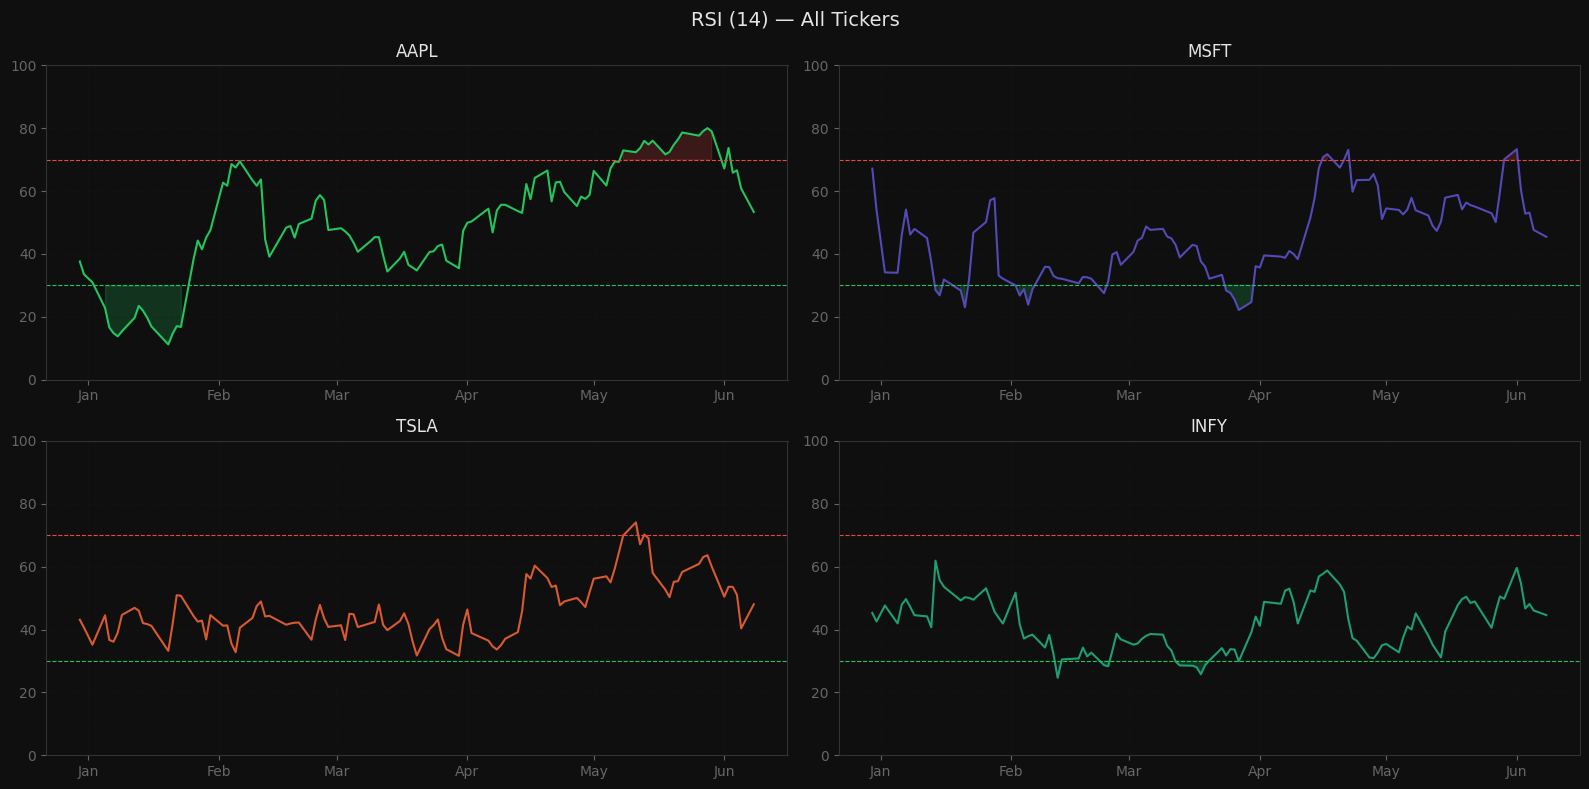

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('RSI (14) — All Tickers', fontsize=14, color='#e5e5e5')
fig.patch.set_facecolor('#0f0f0f')

tickers = ['AAPL', 'MSFT', 'TSLA', 'INFY']
colors  = ['#22c55e', '#534AB7', '#D85A30', '#1D9E75']

for ax, ticker, color in zip(axes.flatten(), tickers, colors):
    s = StockAnalytics(ticker)
    s.run_all()
    data = s.df.dropna(subset=['rsi_14'])

    ax.set_facecolor('#0f0f0f')
    ax.plot(data['date'], data['rsi_14'], color=color, linewidth=1.5)
    ax.axhline(y=70, color='#ef4444', linestyle='--', linewidth=0.8)
    ax.axhline(y=30, color='#22c55e', linestyle='--', linewidth=0.8)
    ax.fill_between(data['date'], data['rsi_14'], 70,
                    where=data['rsi_14'] >= 70, color='#ef4444', alpha=0.2)
    ax.fill_between(data['date'], data['rsi_14'], 30,
                    where=data['rsi_14'] <= 30, color='#22c55e', alpha=0.2)
    ax.set_title(ticker, color='#e5e5e5', fontsize=12)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.savefig('all_rsi.png', dpi=150, bbox_inches='tight')
plt.show()